# calling the important libraries

In [ ]:
# importing libraries like google drive
# pandas
# matplotlib and seaborn
# numpy

import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns



importing the google drive and uploading the file

if files are needed to be uploaded from local machines into colab then use

from google.colab import files

uploaded = files.upload()

In [ ]:
epma = pd.read_excel('/content/Combined Datasets EPMA (1).xlsx',
                             sheet_name= 'epma'
                             )
epma

,SAMPLE,NiO,F,CaO,SiO2,Cr2O3,Na2O,TiO2,V2O3,MnO,MgO,ZnO,FeO,Al2O3,K2O,T
0,KL2023-07-19-4_1,0.005,0.023,22.625,44.409,0.231,0.758,3.365,0.051,0.081,11.749,0.000,5.069,11.660,0.001,3
1,KL2023-07-19-4_2,0.000,0.124,22.752,47.643,0.302,0.764,2.058,0.031,0.017,13.116,0.046,4.967,7.996,0.007,3
2,KL2023-07-19-4_3,0.014,0.000,22.711,49.580,0.189,0.539,1.448,0.033,0.141,14.243,0.000,4.977,5.495,0.004,3
3,KL2023-07-19-4_4,0.000,0.000,23.481,51.316,0.100,0.534,0.057,0.050,0.421,7.376,0.000,16.404,0.564,0.009,3
4,KL2023-07-19-4_5,0.000,0.000,23.601,51.941,0.118,0.423,0.139,0.074,0.388,7.826,0.074,15.199,0.536,0.003,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,KL2023-07-25-8_43,0.000,0.000,23.304,47.393,0.026,0.748,1.640,0.018,0.106,11.943,0.009,7.220,7.173,0.002,2
414,KL2023-07-25-8_44,0.009,0.000,23.196,47.737,0.092,0.603,1.741,0.035,0.136,12.672,0.000,6.285,6.877,0.007,2
415,KL2023-07-25-8_45,0.011,0.098,23.203,46.864,0.031,0.646,1.915,0.045,0.100,13.031,0.000,5.427,8.015,0.016,2
416,KL2023-07-25-8_46,0.018,0.000,23.210,45.340,0.071,0.644,2.295,0.077,0.067,11.945,0.000,6.160,9.679,0.019,2


# reading the dataframe

**first doing some quick statistical observation.**

In [ ]:
epma.describe()

,NiO,F,CaO,SiO2,Cr2O3,Na2O,TiO2,V2O3,MnO,MgO,ZnO,FeO,Al2O3,K2O,T
count,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.00000,418.000000
mean,0.012371,0.019679,22.766269,46.557545,0.120122,0.734468,2.241251,0.040758,0.128551,12.032939,0.019483,6.770477,8.383712,0.00895,1.794258
std,0.018397,0.038296,0.572686,2.171170,0.111609,0.244873,0.694869,0.027708,0.071654,1.804440,0.030741,2.005801,1.941760,0.01140,0.720222
min,0.000000,0.000000,20.626000,39.168000,0.000000,0.226000,0.057000,0.000000,0.017000,5.911000,0.000000,3.856000,0.536000,0.00000,1.000000
25%,0.000000,0.000000,22.415250,45.284750,0.056250,0.605000,1.787500,0.022000,0.085250,11.153525,0.000000,5.508500,7.049250,0.00100,1.000000
50%,0.000000,0.000000,22.792500,46.751000,0.087000,0.663000,2.107500,0.042000,0.113946,12.348500,0.000000,6.258500,8.430775,0.00500,2.000000
75%,0.020750,0.022000,23.183250,48.089750,0.141000,0.768750,2.632750,0.060000,0.150500,13.285750,0.033000,7.336500,9.675500,0.01200,2.000000
max,0.084000,0.223000,24.455000,51.973000,0.707000,1.940000,4.350000,0.179000,0.587000,15.880000,0.156000,16.404000,14.837000,0.11800,3.000000


#**1.Data Quality and Preprocessing of epma dataframe**

Answers of the following questions is given below:

**1.1 Missing Data**: Are there any missing or null values? How should they be addressed (e.g., imputation, removal)?

**1.2 Consistency**: Are the measurements standardized (e.g., same units, consistent significant figures)?

**1.3 Outliers**: Are there outliers in the chemical composition? If so, are they errors or genuinely interesting samples?

**1.4 Coverage**: Does the dataset cover a broad enough range of compositions, or is it skewed toward specific types of clinopyroxene?

**1.1 Missing Data**: Are there any missing or null values? How should they be addressed (e.g., imputation, removal)?

**1.2 Consistency:** Are the measurements standardized (e.g., same units, consistent significant figures)?

In [ ]:
epma['T'] = epma['T'].astype(float)

In [ ]:
# Identify numeric columns
numeric_columns = epma.select_dtypes(include=['float64','int64'])

# Function to calculate the number of decimal places
def decimal_places(value):
    try:
        # Convert to string, split at decimal, and get length of fractional part
        return len(str(value).split(".")[1])
    except (IndexError, ValueError):
        return 0

# Check significant figures consistency
decimal_consistency = numeric_columns.applymap(decimal_places).nunique()

# Display results
decimal_consistency


<ipython-input-138-bbe540a7a4c3>:13: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  decimal_consistency = numeric_columns.applymap(decimal_places).nunique()


,0
NiO,4
F,3
CaO,4
SiO2,4
Cr2O3,5
Na2O,5
TiO2,5
V2O3,3
MnO,4
MgO,4


<ipython-input-139-b2ee1abeca96>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=consistency_data.index, y=consistency_data.values, palette="viridis")


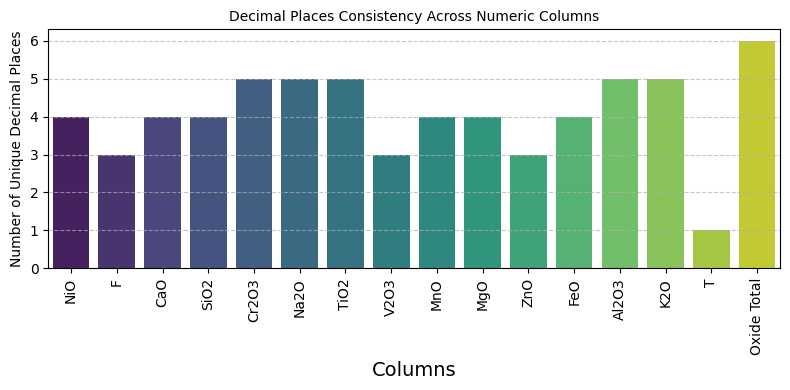

In [ ]:
# Create a colorful bar chart to visualize the decimal places consistency
def plot_decimal_consistency(consistency_data):
    plt.figure(figsize=(8, 4))
    sns.barplot(x=consistency_data.index, y=consistency_data.values, palette="viridis")
    plt.title("Decimal Places Consistency Across Numeric Columns", fontsize=10)
    plt.xlabel("Columns", fontsize=14)
    plt.ylabel("Number of Unique Decimal Places", fontsize=10)
    plt.xticks(rotation=90, fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Call the function to visualize the results
plot_decimal_consistency(decimal_consistency)

**1.3 Outliers: Are there outliers in the oxides or other columns? If so, are they errors or genuinely interesting samples?**

In [ ]:
import numpy as np

# Function to detect outliers using IQR inter quartile range.
def detect_outliers_iqr(epma):
    outliers = {}
    for column in epma.columns:

        if epma[column].dtype in ['float64', 'int64']:  # Only numeric columns

            Q1 = epma[column].quantile(0.25)  # First quartile

            Q3 = epma[column].quantile(0.75)  # Third quartile

            IQR = Q3 - Q1

            lower_bound = Q1 - 1.5 * IQR

            upper_bound = Q3 + 1.5 * IQR

            # Identify outliers

            outlier_values = epma[(epma[column] < lower_bound) | (epma[column] > upper_bound)][column]

            if not outlier_values.empty:

                outliers[column] = outlier_values

    return outliers

# Detect outliers in the numeric columns of "cpx combined"
outliers_sheet1 = detect_outliers_iqr(epma)

# Display results to the user
if outliers_sheet1:

    outliers_df = pd.DataFrame({key: outliers_sheet1[key] for key in outliers_sheet1})

    print("Outliers in Sheet: cpx combined",
          outliers_df)
else:
    print("No outliers detected in the numeric columns of the 'cpx combined' sheet.")
outliers_df

Outliers in Sheet: cpx combined        NiO      F     CaO  SiO2  Cr2O3   Na2O   TiO2  V2O3    MnO    MgO  \
1      NaN  0.124     NaN   NaN  0.302    NaN    NaN   NaN    NaN    NaN   
3      NaN    NaN     NaN   NaN    NaN    NaN  0.057   NaN  0.421  7.376   
4      NaN    NaN     NaN   NaN    NaN    NaN  0.139   NaN  0.388  7.826   
6      NaN    NaN  24.455   NaN    NaN  0.226  0.121   NaN    NaN    NaN   
7      NaN  0.070     NaN   NaN    NaN  1.145    NaN   NaN  0.340    NaN   
..     ...    ...     ...   ...    ...    ...    ...   ...    ...    ...   
405    NaN    NaN     NaN   NaN    NaN    NaN  4.114   NaN    NaN    NaN   
408    NaN  0.060     NaN   NaN    NaN    NaN    NaN   NaN    NaN    NaN   
410  0.059    NaN     NaN   NaN    NaN    NaN    NaN   NaN    NaN    NaN   
411    NaN  0.074     NaN   NaN    NaN    NaN    NaN   NaN    NaN    NaN   
415    NaN  0.098     NaN   NaN    NaN    NaN    NaN   NaN    NaN    NaN   

       ZnO     FeO  Al2O3  K2O  
1      NaN     NaN    

,NiO,F,CaO,SiO2,Cr2O3,Na2O,TiO2,V2O3,MnO,MgO,ZnO,FeO,Al2O3,K2O
1,NaN,0.124,NaN,NaN,0.302,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,0.057,NaN,0.421,7.376,NaN,16.404,0.564,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,0.139,NaN,0.388,7.826,NaN,15.199,0.536,NaN
6,NaN,NaN,24.455,NaN,NaN,0.226,0.121,NaN,NaN,NaN,NaN,10.951,0.687,NaN
7,NaN,0.070,NaN,NaN,NaN,1.145,NaN,NaN,0.340,NaN,0.113,10.693,2.050,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
405,NaN,NaN,NaN,NaN,NaN,NaN,4.114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
408,NaN,0.060,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
410,0.059,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
411,NaN,0.074,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Visualization for outliers**

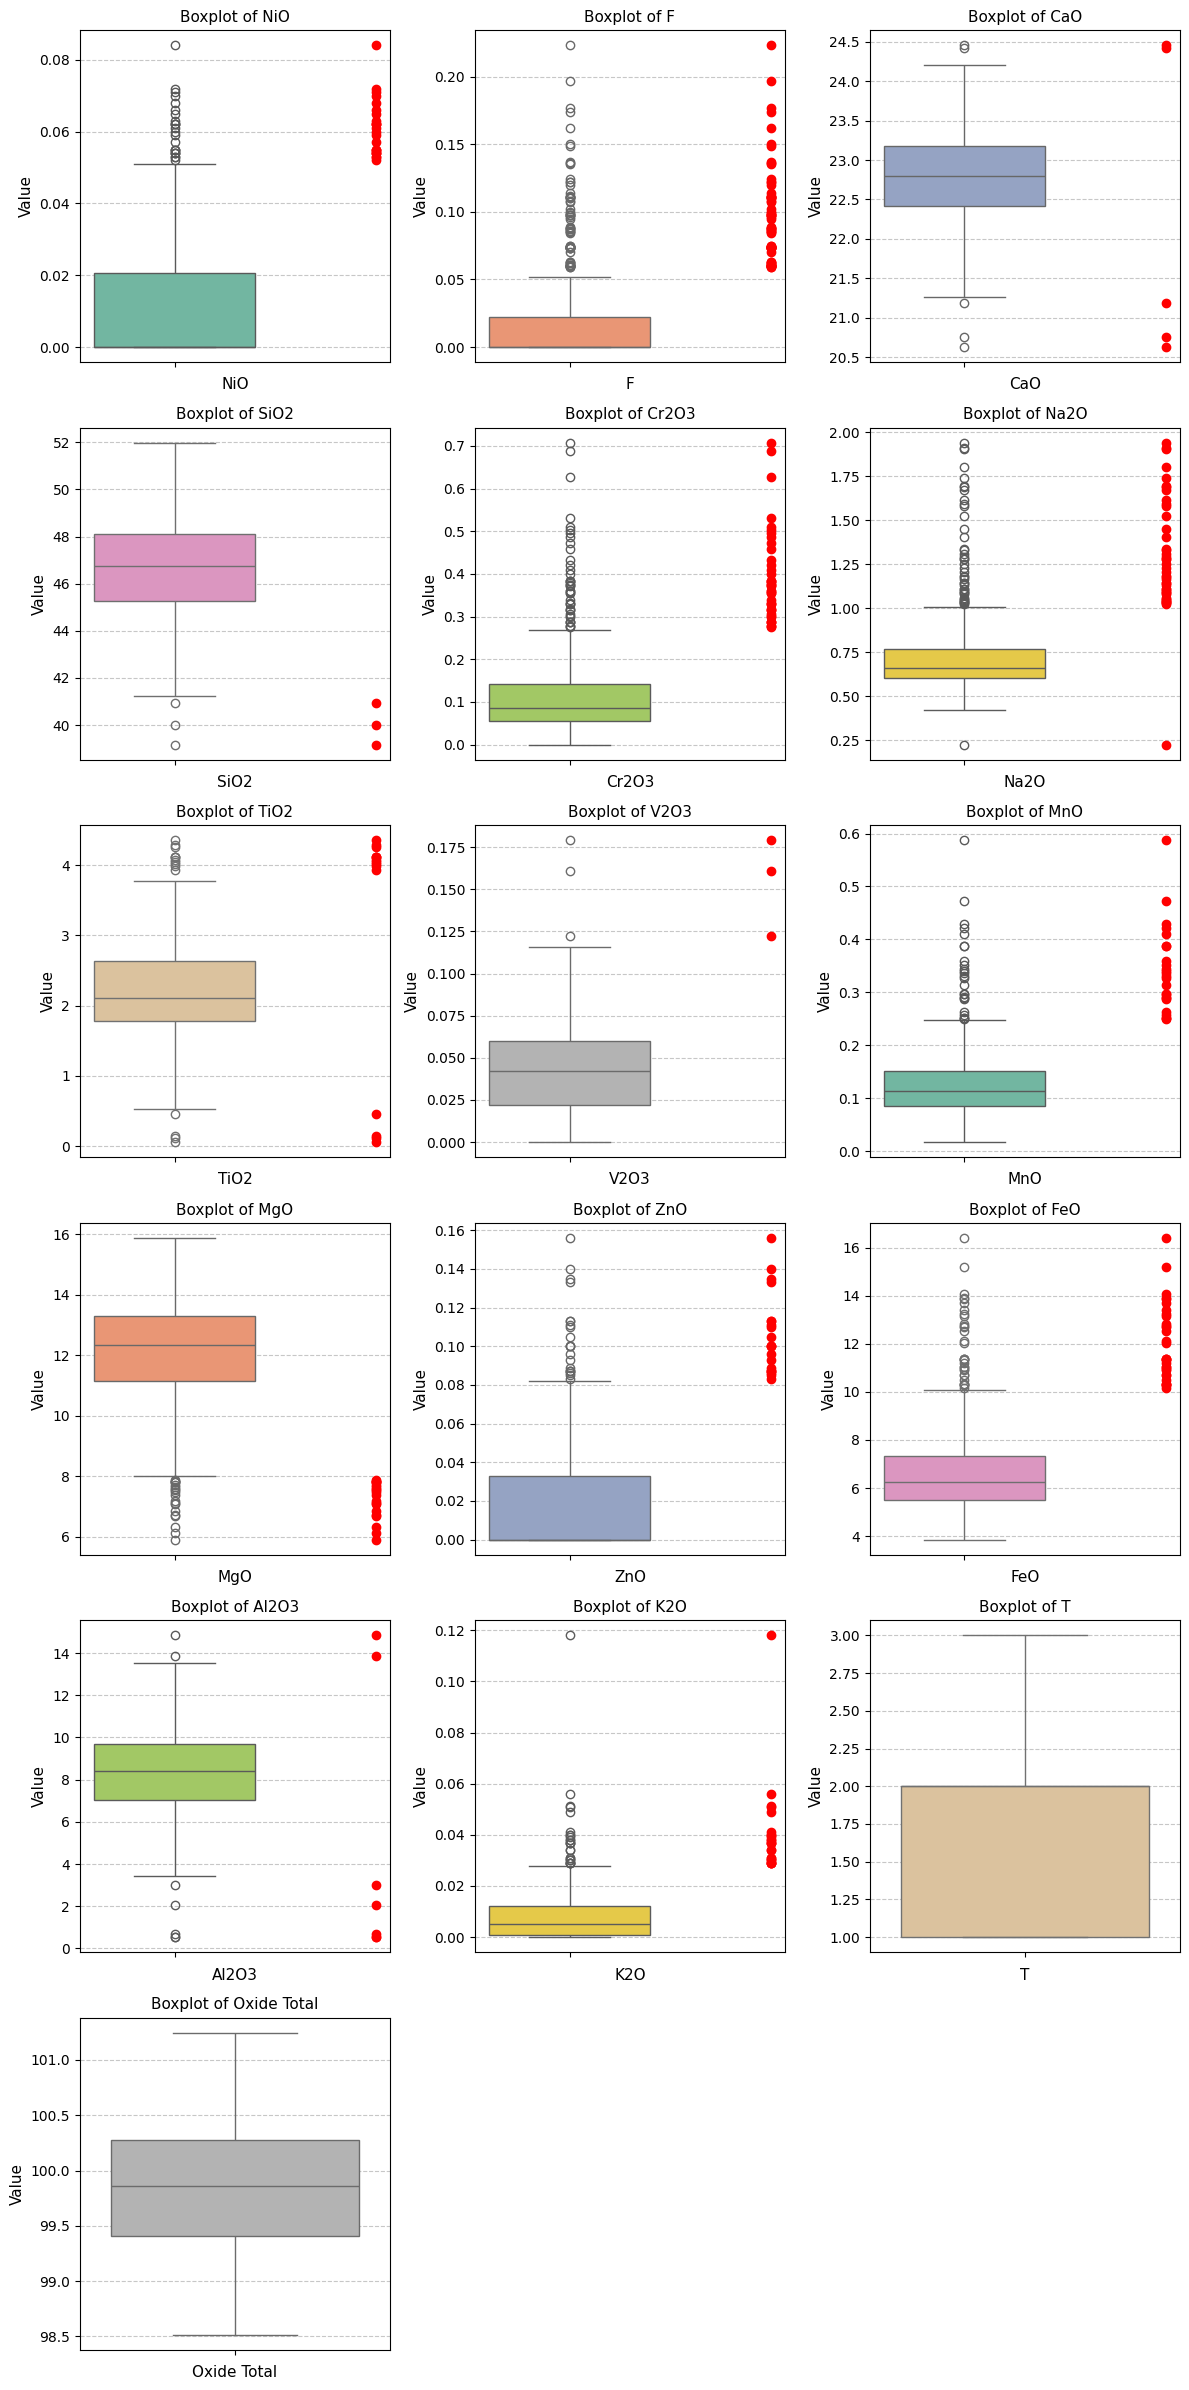

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



# Plot colorful and informative boxplots in subplots
def plot_boxplots(data):
    numeric_columns = data.select_dtypes(include=['float64', 'int64'])
    num_columns = len(numeric_columns.columns)
    num_rows = (num_columns + 2) // 3  # Create rows for 3 columns per row

    fig, axes = plt.subplots(num_rows, 3, figsize=(12, 4 * num_rows))
    axes = axes.flatten()

    for i, column in enumerate(numeric_columns.columns):
        sns.boxplot(data=data[column], ax=axes[i], color=sns.color_palette("Set2")[i % 8])
        axes[i].set_title(f"Boxplot of {column}", fontsize=11)
        axes[i].set_xlabel(column, fontsize=11)
        axes[i].set_ylabel("Value", fontsize=11)
        axes[i].grid(axis='y', linestyle='--', alpha=0.7)

        # Highlight outliers if they exist
        if column in outliers_sheet1:
            outliers = outliers_sheet1[column]
            for outlier in outliers:
                axes[i].scatter(1, outlier, color='red', label='Outlier', zorder=3)
            #axes[i].legend()

    # Hide extra axes
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Call the function to plot boxplots
plot_boxplots(epma)



**1.4 Coverage:**Does the dataset cover a broad enough range of compositions, or is it skewed toward specific types of clinopyroxene?

In [ ]:
epma

,SAMPLE,NiO,F,CaO,SiO2,Cr2O3,Na2O,TiO2,V2O3,MnO,MgO,ZnO,FeO,Al2O3,K2O,T,Oxide Total
0,KL2023-07-19-4_1,0.005,0.023,22.625,44.409,0.231,0.758,3.365,0.051,0.081,11.749,0.000,5.069,11.660,0.001,3.0,100.027
1,KL2023-07-19-4_2,0.000,0.124,22.752,47.643,0.302,0.764,2.058,0.031,0.017,13.116,0.046,4.967,7.996,0.007,3.0,99.823
2,KL2023-07-19-4_3,0.014,0.000,22.711,49.580,0.189,0.539,1.448,0.033,0.141,14.243,0.000,4.977,5.495,0.004,3.0,99.374
3,KL2023-07-19-4_4,0.000,0.000,23.481,51.316,0.100,0.534,0.057,0.050,0.421,7.376,0.000,16.404,0.564,0.009,3.0,100.312
4,KL2023-07-19-4_5,0.000,0.000,23.601,51.941,0.118,0.423,0.139,0.074,0.388,7.826,0.074,15.199,0.536,0.003,3.0,100.322
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,KL2023-07-25-8_43,0.000,0.000,23.304,47.393,0.026,0.748,1.640,0.018,0.106,11.943,0.009,7.220,7.173,0.002,2.0,99.582
414,KL2023-07-25-8_44,0.009,0.000,23.196,47.737,0.092,0.603,1.741,0.035,0.136,12.672,0.000,6.285,6.877,0.007,2.0,99.390
415,KL2023-07-25-8_45,0.011,0.098,23.203,46.864,0.031,0.646,1.915,0.045,0.100,13.031,0.000,5.427,8.015,0.016,2.0,99.402
416,KL2023-07-25-8_46,0.018,0.000,23.210,45.340,0.071,0.644,2.295,0.077,0.067,11.945,0.000,6.160,9.679,0.019,2.0,99.525


==========================================================================================

**To be anwered in thesis separately**

**Data Accuracy**

**Measurement Accuracy:**

Are the measurements accurate and reliable? How was the data collected (e.g., X-ray fluorescence, electron microprobe)?

Were the instruments calibrated?

Is there documentation on error margins for the measurements?

**Validation with Standards:**

Are the results consistent with reference materials or known standards for clinopyroxene?

**Representativeness**

**Geological Representativeness**:

Does the dataset represent a variety of geological environments or is it biased toward specific settings (e.g., igneous vs. metamorphic clinopyroxenes)?


**Temporal Representativeness**:

If applicable, does the dataset cover a significant timespan, or is it limited to a specific time frame?


**Spatial Representativeness:**

Are samples distributed across multiple locations, or is the dataset localized to a few regions?

==============================================================================================

#**Granularity**




**Measurement Precision:**

Are the measurements sufficiently precise to capture subtle variations in composition?

For example, do minor or trace elements have detection limits that are adequate for distinguishing between samples?


while determining granulity, it is found that out of 418 entries only 388 samples are unique.

to identify the duplicated entries.

**Resolution of Data:**

Are the data recorded at a granularity that aligns with the analysis goals (e.g., bulk composition vs. zoning in individual crystals)?

#**Anomalies and Redundancy**

**Duplicate Records:**

Are there duplicate entries in the dataset? If so, are they intentional or errors?


**To check Inconsistencies Across Related Variables:**

Here one extra column called Oxide Total is created.
Do calculated variables (e.g., total oxide percentages) sum to expected values (e.g., ~100%)?



In [ ]:
# Identify rows where the total does not approximate 100%

# (allowing a small margin for measurement error)

expected_total = 100  # Expected total percentage for oxides

inconsistent_totals = epma[~epma['Oxide Total'].between(expected_total - 1, expected_total + 1)]

# Display the inconsistent entries to the user if any exist
if not inconsistent_totals.empty:
    print("Inconsistent Oxide Totals in dataframe:epma")
    print(inconsistent_totals[['Oxide Total']])
else:
    print("No inconsistencies found in the oxide totals for the 'epma_with_age' dataframe.")


Inconsistent Oxide Totals in dataframe:epma
     Oxide Total
5      98.907000
10     98.770000
13     98.830000
16     98.686000
30     98.554000
53     98.703000
65     98.868000
71     98.780321
109    98.824000
112    98.882000
118    98.745000
127    98.805000
128    98.643403
129    98.673068
130    98.898058
131    98.929000
133    98.941000
138    98.898787
142    98.848647
144    98.960238
146    98.800200
147    98.745042
149    98.516000
151    98.882000
155    98.981000
163    98.728000
164    98.822000
167    98.831000
169    98.992000
175    98.924000
176    98.712000
184    98.874000
192    98.550000
194    98.769000
232   101.035000
280    98.705000
286   101.097000
287   101.016000
288   101.244000
339   101.028000
353    98.645000
357    98.576113
358    98.930906
405    98.866000


**Logical Anomalies:**

Are there logical inconsistencies in the data (e.g., negative values for oxide percentages, physically impossible values)?

In [ ]:
# Check for logical anomalies in the dataset
logical_anomalies = {}

# Negative value check in numeric columns
negative_values = numeric_columns[(numeric_columns < 0).any(axis=1)]


# Physically impossible values (e.g., oxide percentages > 100%)
impossible_values = numeric_columns[(numeric_columns > 100).any(axis=1)]

# Store anomalies for reporting
logical_anomalies['Negative Values'] = negative_values

logical_anomalies['Impossible Values'] = impossible_values

# Display anomalies to the user if any exist

if not negative_values.empty:

    print("Negative Values in epma_with_age",negative_values)

if not impossible_values.empty:

    print("Impossible Values in epma_with_age")
    print(impossible_values[['Oxide Total']])

# If no anomalies are found

if negative_values.empty and impossible_values.empty:

    print("No logical anomalies (e.g., negative or physically impossible values) found in the epma_with_age dataframe.")


Impossible Values in epma_with_age
     Oxide Total
0        100.027
3        100.312
4        100.322
17       100.297
18       100.179
..           ...
407      100.256
408      100.491
409      100.158
410      100.084
411      100.299

[179 rows x 1 columns]


In [ ]:
# Filter the rows where 'total' and 'total with Li2O' are greater than 100
filtered_entries = epma[(epma['Oxide Total'] > 100)]

# Display the filtered entries
print("Entries where 'total' and 'total with Li2O' are greater than 100:")
filtered_entries[['SAMPLE','Oxide Total']]

Entries where 'total' and 'total with Li2O' are greater than 100:


,SAMPLE,Oxide Total
0,KL2023-07-19-4_1,100.027
3,KL2023-07-19-4_4,100.312
4,KL2023-07-19-4_5,100.322
17,KL2023-07-19-6_1,100.297
18,KL2023-07-19-6_2,100.179
...,...,...
407,KL2023-07-25-8_37,100.256
408,KL2023-07-25-8_38,100.491
409,KL2023-07-25-8_39,100.158
410,KL2023-07-25-8_40,100.084


=============================================================================================

**Documentation and Metadata**

**Metadata Completeness:**

Is there sufficient metadata (e.g., sample IDs, collection methods, geological context) to interpret the data?


**Versioning:**

Is there clear documentation of data versions or any preprocessing steps applied to the data?

============================================================================================

**Noise and Signal**

**Signal-to-Noise Ratio:**

Does the dataset have a high signal-to-noise ratio, or is there significant variability that might obscure meaningful trends?


**Measurement Error:**

Are uncertainties in measurements explicitly reported, especially for trace elements?

===================================================================================================================

**Signal-to-Noise Ratio:**

Does the dataset have a high signal-to-noise ratio, or is there significant variability that might obscure meaningful trends?

In [ ]:
# Select numeric columns only

numeric_columns = epma.select_dtypes(include=['float64', 'int64'])

# Calculate Signal-to-Noise Ratio (SNR) for each numeric column

# SNR = Mean / Standard Deviation

snr_analysis = numeric_columns.mean() / numeric_columns.std()

# Display the SNR analysis
print("Signal-to-Noise Ratio Analysis:")

print(snr_analysis)

'''
# Save the SNR analysis to a CSV if needed
snr_analysis.to_csv('snr_analysis.csv', index=True)
'''

Signal-to-Noise Ratio Analysis:
NiO              0.672423
F                0.513872
CaO             39.753491
SiO2            21.443529
Cr2O3            1.076271
Na2O             2.999384
TiO2             3.225430
V2O3             1.471011
MnO              1.794069
MgO              6.668516
ZnO              0.633786
FeO              3.375448
Al2O3            4.317583
K2O              0.785066
T                2.491257
Oxide Total    171.590620
dtype: float64


"\n# Save the SNR analysis to a CSV if needed\nsnr_analysis.to_csv('snr_analysis.csv', index=True)\n"

<ipython-input-148-7028fa6aee0c>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data.values, y=data.index, palette="coolwarm", orient='h')


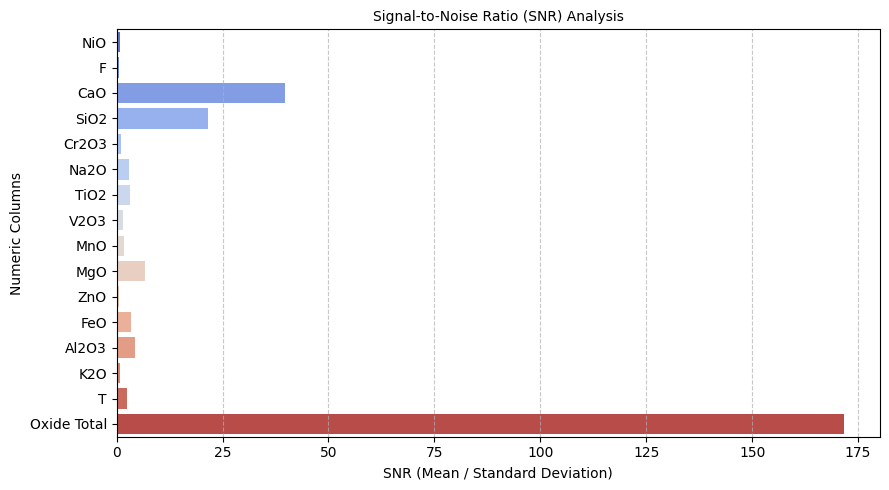

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


# Plot the SNR analysis as a horizontal bar chart
def plot_snr(data):
    plt.figure(figsize=(9, 5))
    sns.barplot(x=data.values, y=data.index, palette="coolwarm", orient='h')
    plt.title("Signal-to-Noise Ratio (SNR) Analysis", fontsize=10)
    plt.xlabel("SNR (Mean / Standard Deviation)", fontsize=10)
    plt.ylabel("Numeric Columns", fontsize=10)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Call the function to plot SNR
plot_snr(snr_analysis)



**Measurement Error:**

Are uncertainties in measurements explicitly reported, especially for trace elements?

using Standard deviation as proxy for measurement errors. i step two

In [ ]:


# Select numeric columns only
numeric_columns = epma.select_dtypes(include=['float64', 'int64'])

# Step 1: Identify explicit uncertainty columns (if labeled or paired)

# Look for columns with names indicating uncertainty (e.g., "Error", "Uncertainty")

uncertainty_columns = [col for col in epma.columns if 'error' in col.lower() or 'uncertainty' in col.lower()]

if uncertainty_columns:
    print("Explicit uncertainty columns found:")
    print(uncertainty_columns)
    # Display uncertainties alongside corresponding measurements
    uncertainty_data = epma[uncertainty_columns]
    print("\nUncertainty data:")
    print(uncertainty_data)
else:
    print("No explicit uncertainty columns found.")


# Step 2: Infer uncertainties based on STATISTICAL VARIABILITY

# Use the standard deviation as a proxy for uncertainty if not explicitly provided

measurement_errors = numeric_columns.std()

# Step 3: Display measurement errors (standard deviations)

print("\nInferred measurement errors (Standard Deviations):")

print(measurement_errors)



No explicit uncertainty columns found.

Inferred measurement errors (Standard Deviations):
NiO            0.018397
F              0.038296
CaO            0.572686
SiO2           2.171170
Cr2O3          0.111609
Na2O           0.244873
TiO2           0.694869
V2O3           0.027708
MnO            0.071654
MgO            1.804440
ZnO            0.030741
FeO            2.005801
Al2O3          1.941760
K2O            0.011400
T              0.720222
Oxide Total    0.581830
dtype: float64



Inferred Measurement Errors (Standard Deviations):
NiO            0.018397
F              0.038296
CaO            0.572686
SiO2           2.171170
Cr2O3          0.111609
Na2O           0.244873
TiO2           0.694869
V2O3           0.027708
MnO            0.071654
MgO            1.804440
ZnO            0.030741
FeO            2.005801
Al2O3          1.941760
K2O            0.011400
T              0.720222
Oxide Total    0.581830
dtype: float64


<ipython-input-150-9b328efa497f>:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=errors.index, y=errors.values, palette="viridis")


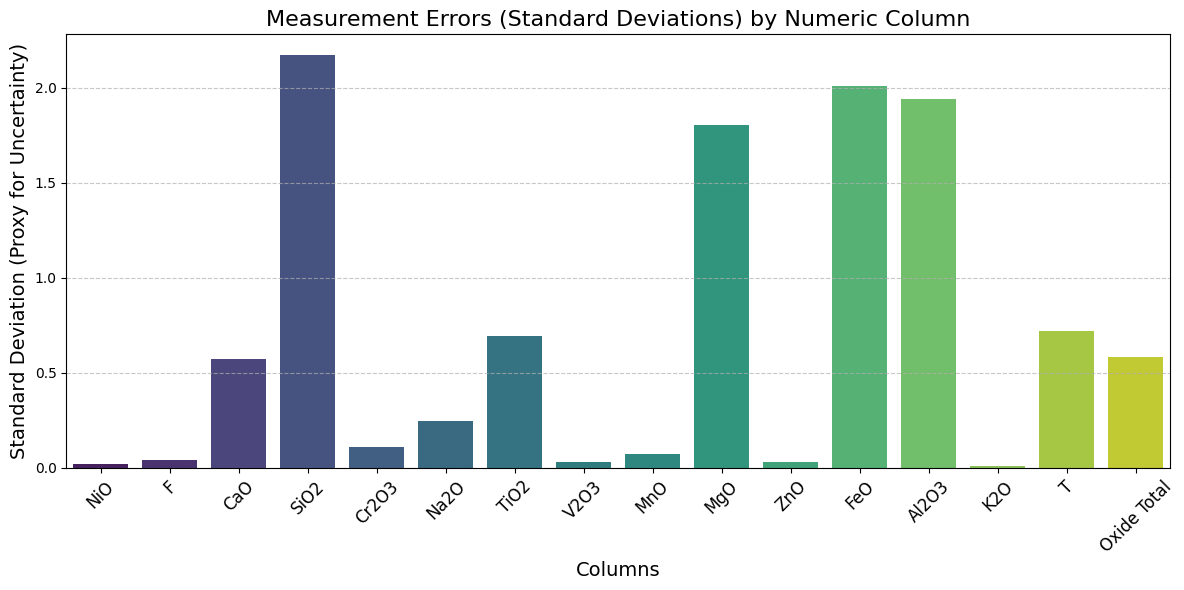

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


# Step 1: Visualize measurement errors (standard deviations)

def plot_measurement_errors(errors):

    plt.figure(figsize=(12, 6))

    sns.barplot(x=errors.index, y=errors.values, palette="viridis")

    plt.title("Measurement Errors (Standard Deviations) by Numeric Column", fontsize=16)

    plt.xlabel("Columns", fontsize=14)

    plt.ylabel("Standard Deviation (Proxy for Uncertainty)", fontsize=14)

    plt.xticks(rotation=45, fontsize=12)

    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()

    plt.show()


print("\nInferred Measurement Errors (Standard Deviations):")

print(measurement_errors)

plot_measurement_errors(measurement_errors)


================================================================================================================================================================

#**Normalization and Scaling**


**Normalization Issues:**

Are there discrepancies in normalization (e.g., oxides normalized to 100%)?

Are unnormalized datasets consistent?



=====================================================================================================================

**Normalization Issues:**

Are there discrepancies in normalization (e.g., oxides normalized to 100%)?

Are unnormalized datasets consistent?

In [ ]:
epma.dtypes

,0
SAMPLE,object
NiO,float64
F,float64
CaO,float64
SiO2,float64
Cr2O3,float64
Na2O,float64
TiO2,float64
V2O3,float64
MnO,float64


In [ ]:


epma1 = epma[['NiO', 'F', 'CaO', 'SiO2', 'Cr2O3', 'Na2O', 'TiO2', 'V2O3',
                        'MnO', 'MgO', 'ZnO', 'FeO', 'Al2O3', 'K2O', 'T',]]

epma1.dtypes

,0
NiO,float64
F,float64
CaO,float64
SiO2,float64
Cr2O3,float64
Na2O,float64
TiO2,float64
V2O3,float64
MnO,float64
MgO,float64


In [ ]:
# Ensure all columns are numeric
epma1= epma1.apply(pd.to_numeric, errors='coerce').fillna(0)

In [ ]:

df_normalized = epma1.div(epma1.sum(axis=1),
                                   axis=0) * 100

df_normalized

,NiO,F,CaO,SiO2,Cr2O3,Na2O,TiO2,V2O3,MnO,MgO,ZnO,FeO,Al2O3,K2O,T
0,0.004853,0.022324,21.960263,43.104235,0.224213,0.735729,3.266134,0.049502,0.078620,11.403807,0.000000,4.920069,11.317422,0.000971,2.911858
1,0.000000,0.120596,22.127345,46.334964,0.293709,0.743024,2.001498,0.030149,0.016533,12.755901,0.044737,4.830631,7.776470,0.006808,2.917635
2,0.013675,0.000000,22.184344,48.430265,0.184617,0.526501,1.414422,0.032235,0.137730,13.912712,0.000000,4.861586,5.367574,0.003907,2.930432
3,0.000000,0.000000,22.728241,49.670900,0.096794,0.516881,0.055173,0.048397,0.407503,7.139538,0.000000,15.878117,0.545919,0.008711,2.903825
4,0.000000,0.000000,22.842183,50.270997,0.114206,0.409400,0.134531,0.071621,0.375525,7.574379,0.071621,14.710323,0.518767,0.002904,2.903544
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,0.000000,0.000000,22.941072,46.654919,0.025595,0.736351,1.614459,0.017720,0.104349,11.757004,0.008860,7.107558,7.061290,0.001969,1.968853
414,0.008877,0.000000,22.877996,47.082553,0.090739,0.594733,1.717132,0.034520,0.134136,12.498274,0.000000,6.198836,6.782720,0.006904,1.972581
415,0.010848,0.096645,22.882192,46.216051,0.030571,0.637068,1.888523,0.044378,0.098617,12.850831,0.000000,5.351965,7.904183,0.015779,1.972348
416,0.017730,0.000000,22.861364,44.658951,0.069934,0.634327,2.260527,0.075843,0.065994,11.765575,0.000000,6.067471,9.533612,0.018715,1.969958


In [ ]:

# Checking discrepancies in normalization (whether the sum is 100% per row)
df_normalized['Sum'] = df_normalized.iloc[:,0:15].sum(axis=1)

discrepancies = df_normalized[df_normalized['Sum'] != 100]

df_normalized

# Check if the sum of oxides is consistent across rows (i.e., no huge deviations)

consistency_check1 = df_normalized['Sum'].std()  # Standard deviation of the sum of oxides across rows


In [ ]:
# Checking consistency in unnormalized datasets

# Calculate the sum of oxides per row in the original (unnormalized) dataset
epma['Sum']=epma[['NiO', 'F', 'CaO', 'SiO2', 'Cr2O3', 'Na2O', 'TiO2', 'V2O3',

                                                  'MnO', 'MgO', 'ZnO', 'FeO', 'Al2O3', 'K2O']].sum(axis=1)

# Check if the sum of oxides is consistent across rows (i.e., no huge deviations)

consistency_check2 = epma['Sum'].std()  # Standard deviation of the sum of oxides across rows




In [ ]:
# Output the results
print("Normalized Data (Oxides Summed to 100%):")

print(df_normalized)

print(f"Standard Deviation: {consistency_check1}")

print("\nDiscrepancies in Normalization (Oxides Sum Not 100%):")

print(discrepancies)

print("\nOriginal (Unnormalized) Data with Sum of Oxides:")

print(epma)

print("\nStandard Deviation of Oxides Sum in Unnormalized Data (Consistency Check):")

print(f"Standard Deviation: {consistency_check2}")


Normalized Data (Oxides Summed to 100%):
          NiO         F        CaO       SiO2     Cr2O3      Na2O      TiO2  \
0    0.004853  0.022324  21.960263  43.104235  0.224213  0.735729  3.266134   
1    0.000000  0.120596  22.127345  46.334964  0.293709  0.743024  2.001498   
2    0.013675  0.000000  22.184344  48.430265  0.184617  0.526501  1.414422   
3    0.000000  0.000000  22.728241  49.670900  0.096794  0.516881  0.055173   
4    0.000000  0.000000  22.842183  50.270997  0.114206  0.409400  0.134531   
..        ...       ...        ...        ...       ...       ...       ...   
413  0.000000  0.000000  22.941072  46.654919  0.025595  0.736351  1.614459   
414  0.008877  0.000000  22.877996  47.082553  0.090739  0.594733  1.717132   
415  0.010848  0.096645  22.882192  46.216051  0.030571  0.637068  1.888523   
416  0.017730  0.000000  22.861364  44.658951  0.069934  0.634327  2.260527   
417  0.020621  0.000000  22.701742  44.582572  0.147293  0.551857  2.658143   

         V

**Scaling Problems:**

Are some variables disproportionately large or small, making it hard to analyze the data without scaling?

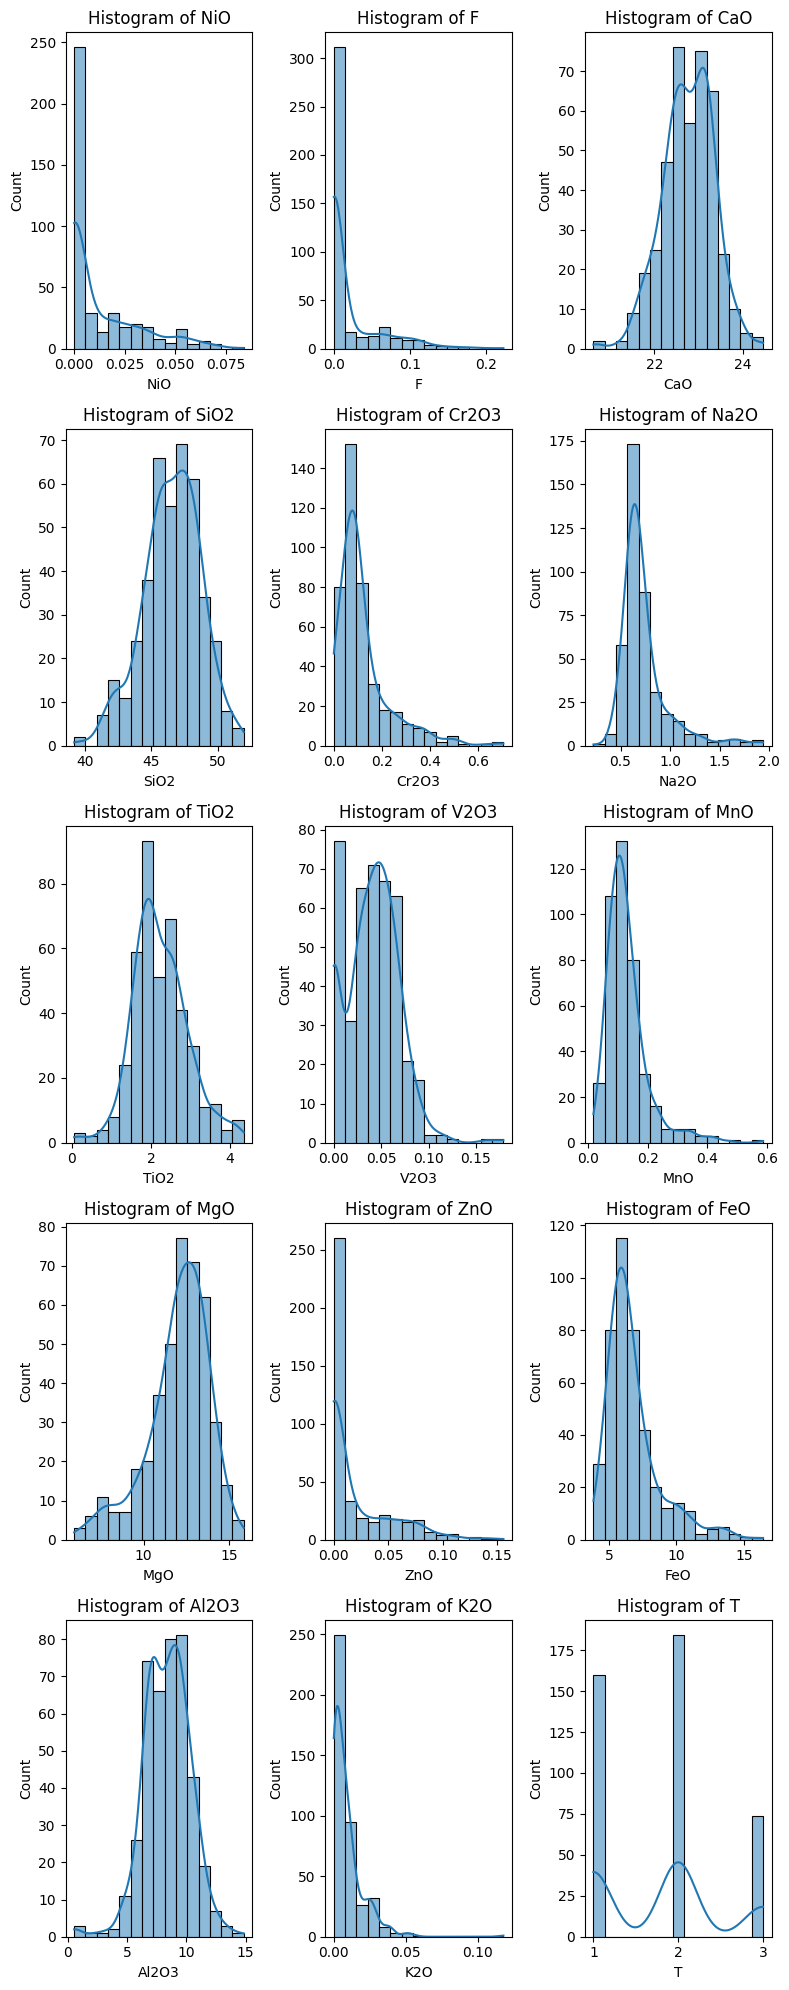

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Example function to plot histograms and boxplots for each feature
def plot_distribution(data):

    # Calculate the number of subplots required
    num_columns = len(data.columns)

    # Adjust subplot grid based on number of columns (here using ceil to ensure enough rows/cols)
    num_rows = (num_columns + 1) // 3  # Creates rows of 2 plots each

    # Create subplots: one for histogram, one for boxplot
    fig, axes = plt.subplots(num_rows, 3, figsize=(8, 4 * num_rows))

    # Flatten axes array if it's 2D (for easier indexing)
    axes = axes.flatten()

    for i, col in enumerate(data.columns):
        # Histogram with KDE (Kernel Density Estimate)
        sns.histplot(data[col],
                     ax=axes[i],
                     kde=True,
                     bins=15)

        axes[i].set_title(f"Histogram of {col}")

    # Remove extra axes (if any)
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')  # Hide unused subplots

    # Adjust layout to prevent overlap
    plt.tight_layout()
    plt.show()

# Call the function on your data
plot_distribution(epma1)


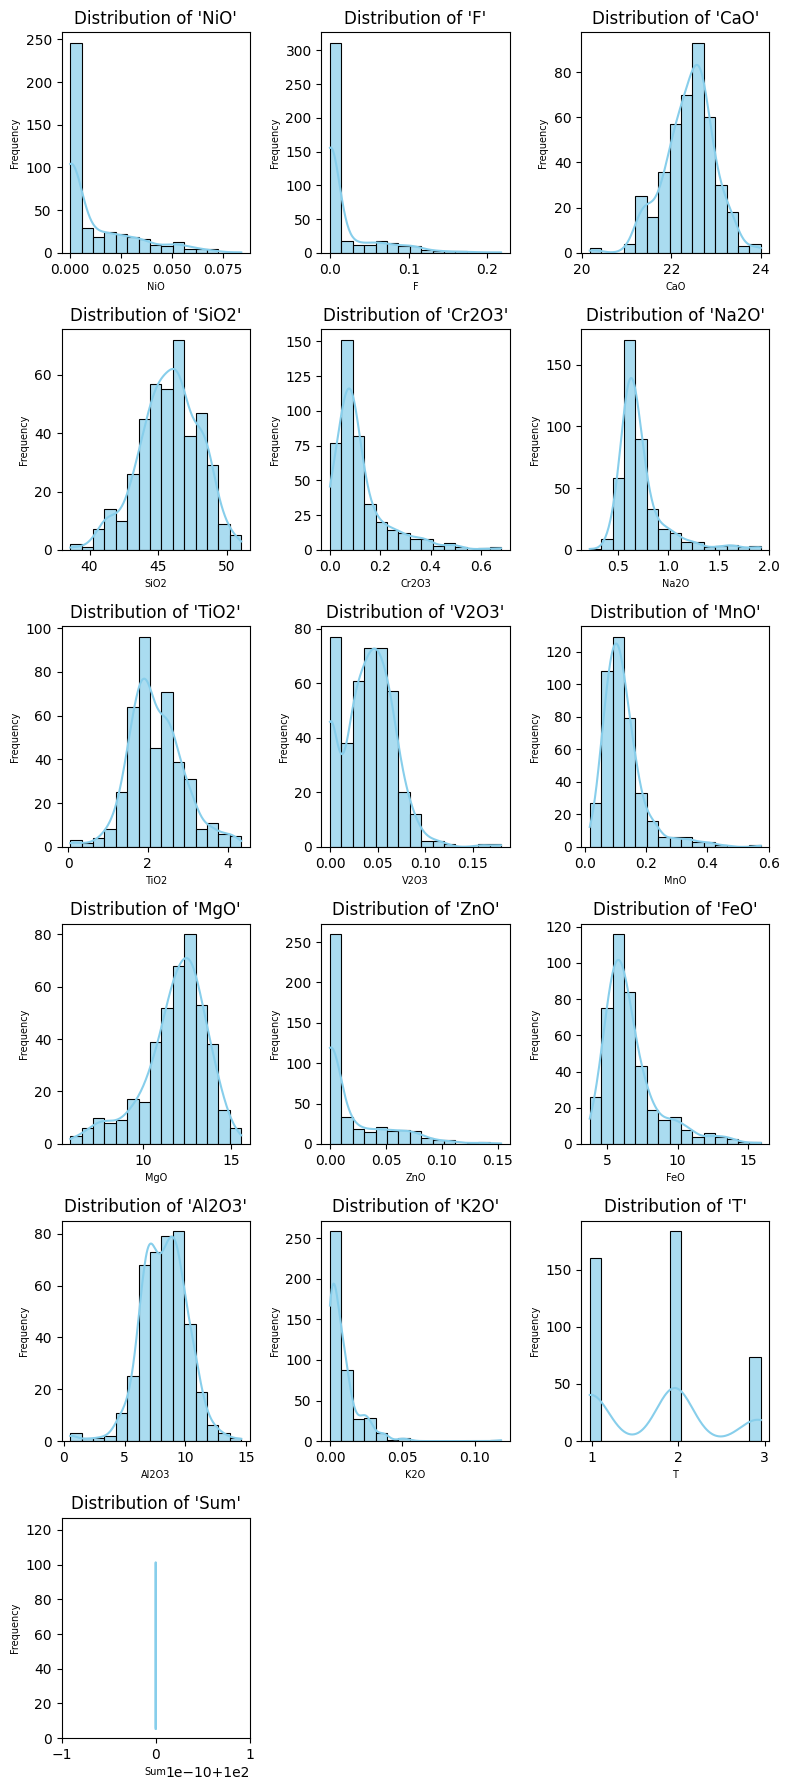

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Function to plot histograms and boxplots for each feature
def plot_distribution(data):
    """
    Plots histograms with KDEs for each column in the dataset.

    Parameters:
    - data: pandas DataFrame containing numerical columns to visualize.

    Displays:
    - A grid of subplots with histograms and KDEs for each column in the data.
    """
    # Number of columns to plot
    num_columns = len(data.columns)

    # Determine grid size for subplots
    num_rows = math.ceil(num_columns / 3)  # 3 columns per row

    # Create subplots
    fig, axes = plt.subplots(num_rows, 3, figsize=(8, 3 * num_rows))  # Adjust figure size
    axes = axes.flatten()  # Flatten axes for easy indexing

    for i, col in enumerate(data.columns):
        # Plot histogram with KDE
        sns.histplot(
            data[col],
            ax=axes[i],
            kde=True,
            bins=15,
            color='skyblue',
            edgecolor='black',
            alpha=0.7
        )

        # Set titles and labels
        axes[i].set_title(f"Distribution of '{col}'", fontsize=12)
        axes[i].set_xlabel(col, fontsize=7)
        axes[i].set_ylabel("Frequency", fontsize=7)

    # Hide unused axes if the grid is larger than required
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')  # Hide extra subplots

    # Adjust layout for better spacing
    plt.tight_layout()

    # Display the plots
    plt.show()

# Call the function on your dataset
plot_distribution(df_normalized)


IndexError: index 2 is out of bounds for axis 0 with size 2

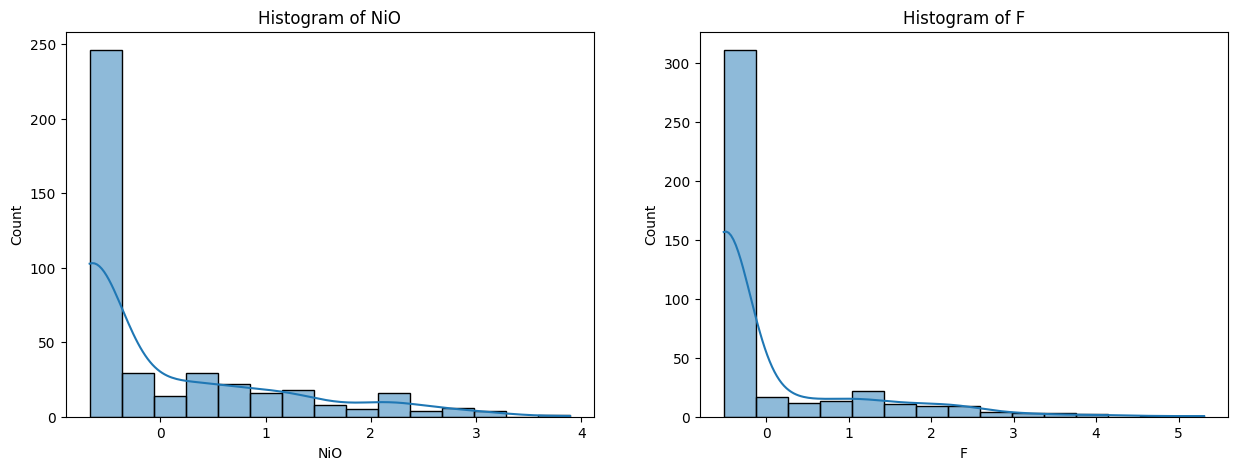

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



# Step 1: Check the range (min, max) of each column to identify scale issues
range_data = epma.describe().T[['min', 'max']]


'''
# Step 2: Visualize the distribution of each feature (histograms and boxplots)
def plot_distribution(data):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    for i, col in enumerate(df_standardized.columns):
        sns.histplot(df_standardized[col], ax=axes[i], kde=True, bins=15)
        axes[i].set_title(f"Histogram of {col}")
    plt.tight_layout()
    plt.show()

# Visualizing the unscaled data distributions
plot_distribution(df_standardized)

'''

# Step 3: Check for large differences in the scale (variance)
scaling_issue_check = epma1.std()

# Step 4: Apply Standardization (Z-score normalization) and Min-Max normalization to check effects

# Standardization (Z-score normalization)
df_standardized = (epma1 - epma1.mean()) / epma1.std()

# Min-Max Normalization (scaling between 0 and 1)
df_min_max = (epma1 - epma1.min()) / (epma1.max() - epma1.min())

# Visualizing the transformed data distributions (after scaling)
plot_distribution(df_standardized)

plot_distribution(df_min_max)

# Step 5: Compare the original and scaled data for scaling issues
print("Range of original data (min, max):")
print(range_data)

print("\nStandard deviations of original data (indicative of scale differences):")
print(scaling_issue_check)

# Output the results after scaling
print("\nStandardized Data (Z-score normalization):")
print(df_standardized)

print("\nMin-Max Normalized Data:")
print(df_min_max)


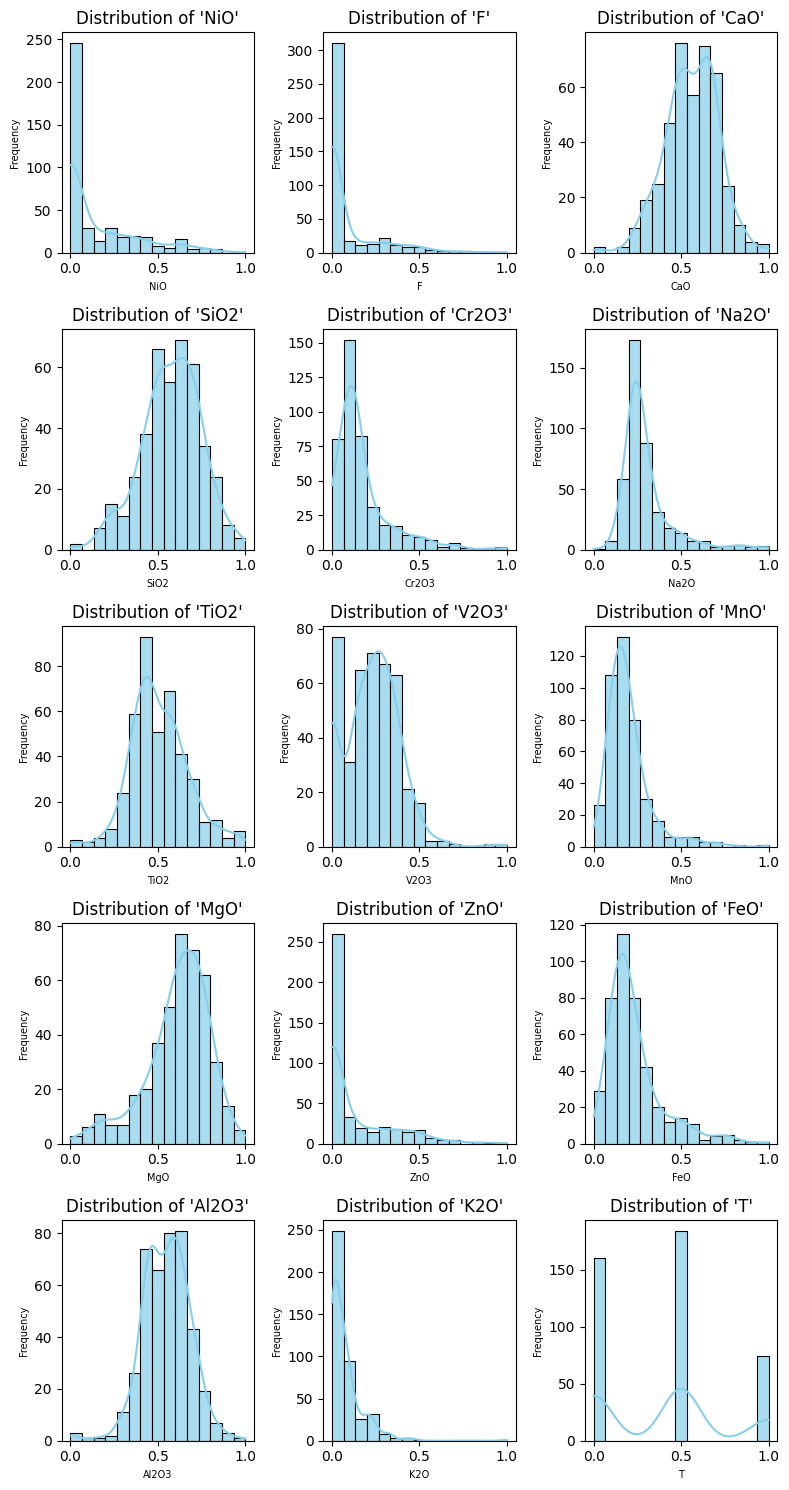

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Function to plot histograms and boxplots for each feature
def plot_distribution(data):
    """
    Plots histograms with KDEs for each column in the dataset.

    Parameters:
    - data: pandas DataFrame containing numerical columns to visualize.

    Displays:
    - A grid of subplots with histograms and KDEs for each column in the data.
    """
    # Number of columns to plot
    num_columns = len(data.columns)

    # Determine grid size for subplots
    num_rows = math.ceil(num_columns / 3)  # 3 columns per row

    # Create subplots
    fig, axes = plt.subplots(num_rows, 3, figsize=(8, 3 * num_rows))  # Adjust figure size
    axes = axes.flatten()  # Flatten axes for easy indexing

    for i, col in enumerate(data.columns):
        # Plot histogram with KDE
        sns.histplot(
            data[col],
            ax=axes[i],
            kde=True,
            bins=15,
            color='skyblue',
            edgecolor='black',
            alpha=0.7
        )

        # Set titles and labels
        axes[i].set_title(f"Distribution of '{col}'", fontsize=12)
        axes[i].set_xlabel(col, fontsize=7)
        axes[i].set_ylabel("Frequency", fontsize=7)

    # Hide unused axes if the grid is larger than required
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')  # Hide extra subplots

    # Adjust layout for better spacing
    plt.tight_layout()

    # Display the plots
    plt.show()

# Call the function on your dataset
plot_distribution(df_min_max)
